In [53]:
import numpy as np
import pandas as pd 
import sklearn as skl
import matplotlib.pyplot as plt 


In [54]:
# Load Iris 
from sklearn.datasets import load_iris 

data  = load_iris(as_frame=True)
X = data.data
y = data.target
X= pd.DataFrame(data=X)
y= pd.DataFrame(data=y) 


print(f"X: {X.shape}\ny: {y.shape}")
print(f"X: {X.columns.values}\ny: {y.columns.values}")

X: (150, 4)
y: (150, 1)
X: ['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']
y: ['target']


In [55]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [56]:
print(X.isna().value_counts())

sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
False              False             False              False               150
Name: count, dtype: int64


In [57]:
print(y.value_counts())

target
0         50
1         50
2         50
Name: count, dtype: int64


Melhores Parâmetros: {'tree__criterion': 'gini', 'tree__max_depth': 2}
Acurácia média (CV): 0.9281


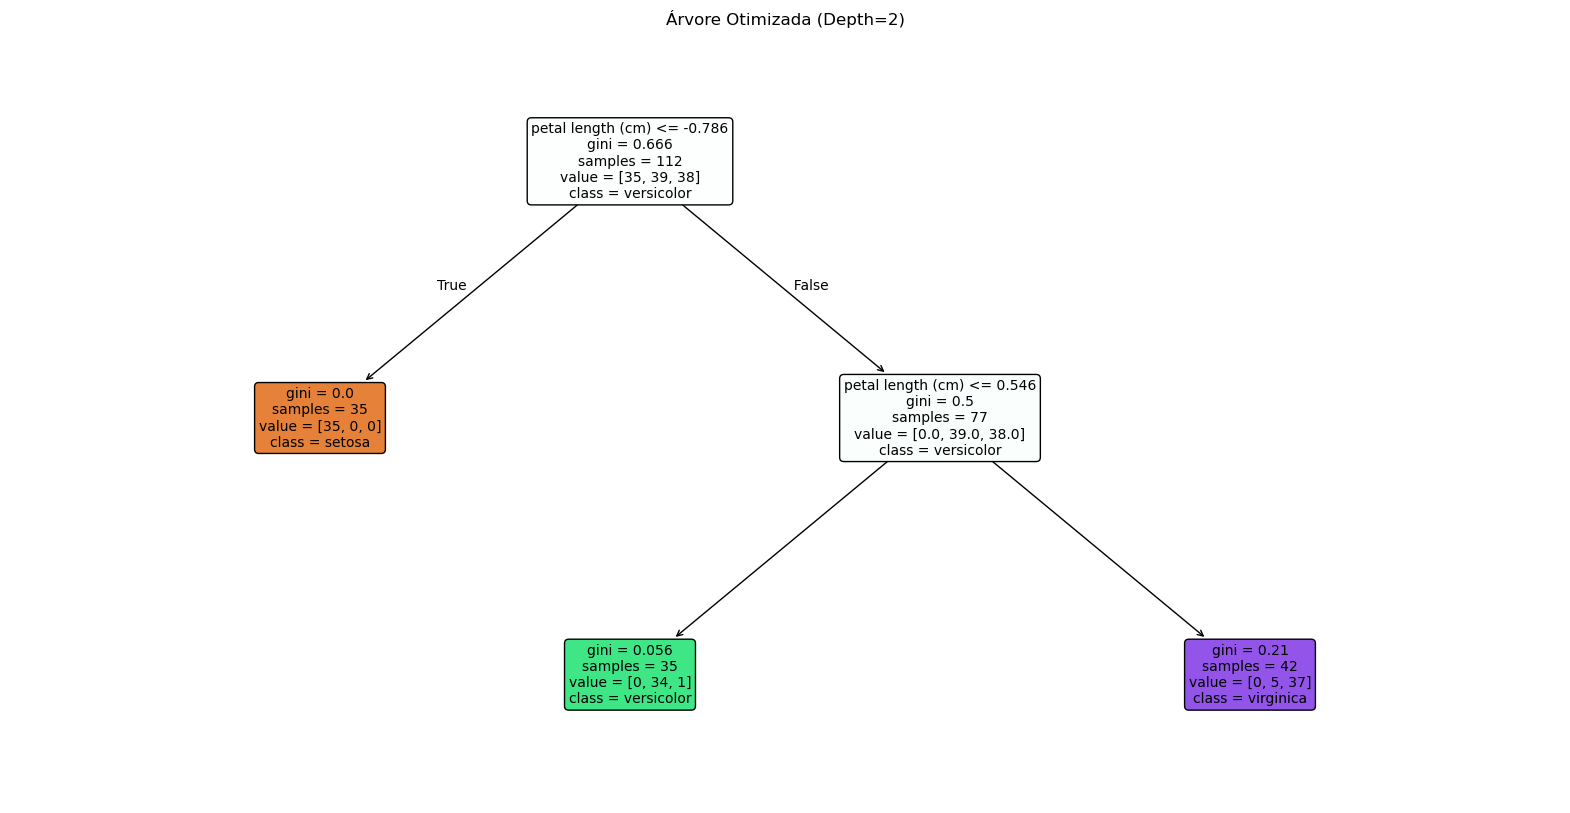

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from  sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y,  random_state=42, shuffle= True)

pipeline = Pipeline([
    ("scale", StandardScaler()),
    ('tree', DecisionTreeClassifier(random_state=42))
])

# Definir os parâmetros que queremos testar
param_grid = {
    'tree__max_depth': [2, 3, 5, 10],
    'tree__criterion': ['gini', 'entropy']
}
kf = KFold(n_splits=5,  shuffle=True, random_state=42)


grid_search  = GridSearchCV(pipeline, param_grid, cv=kf, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 4. Validação Cruzada do MELHOR modelo encontrado
best_model = grid_search.best_estimator_
scores = cross_validate(best_model, X_train, y_train, cv=kf)

print(f"Melhores Parâmetros: {grid_search.best_params_}")
print(f"Acurácia média (CV): {scores['test_score'].mean():.4f}")

# 5. Visualização da Melhor Árvore
plt.figure(figsize=(20, 10))
plot_tree(best_model.named_steps['tree'], # Acessando a árvore dentro do pipeline
          feature_names=data.feature_names, # Se disponível (ex: Iris)
          class_names=data.target_names,    # Se disponível
          filled=True,
          rounded=True,
          fontsize=10)
plt.title(f"Árvore Otimizada (Depth={grid_search.best_params_['tree__max_depth']})")
plt.show()

